<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [1]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

### Datos
Utilizaremos como dataset canciones de bandas de habla inglés.

In [2]:
# descargar de textos.info
import urllib.request

# Para leer y parsear el texto en HTML de wikipedia
import bs4 as bs

In [3]:
raw_html = urllib.request.urlopen('https://www.textos.info/julio-verne/la-vuelta-al-mundo-en-80-dias/ebook')
raw_html = raw_html.read()

# Parsear artículo, 'lxml' es el parser a utilizar
article_html = bs.BeautifulSoup(raw_html, 'lxml')

# Encontrar todos los párrafos del HTML (bajo el tag <p>)
# y tenerlos disponible como lista
article_paragraphs = article_html.find_all('p')

article_text = ''

for para in article_paragraphs:
    article_text += para.text + ' '

# pasar todo el texto a minúscula
article_text = article_text.lower()

In [4]:
# en article text se encuentra el texto de todo el libro
article_text[:1000]

' en el año 1872, la casa número 7 de saville-row, burlington gardens \n—donde murió sheridan en 1814— estaba habitada por phileas fogg, quien a\n pesar de que parecía haber tomado el partido de no hacer nada que \npudiese llamar la atención, era uno de los miembros más notables y \nsingulares del reformclub de londres. por consiguiente, phileas fogg, personaje enigmático y del cual sólo \nse sabía que era un hombre muy galante y de los más cumplidos gentlemen \nde la alta sociedad inglesa, sucedía a uno de los más grandes oradores \nque honran a inglaterra. decíase que se daba un aire a lo byron —su cabeza, se entiende, \nporque, en cuanto a los pies, no tenía defecto alguno—, pero a un byron \nde bigote y pastillas, a un byron impasible, que hubiera vivido mil años\n sin envejecer. phileas fogg, era inglés de pura cepa; pero quizás no había nacido en\n londres. jamás se le había visto en la bolsa ni en el banco, ni en \nninguno de los despachos mercantiles de la city. ni las dársenas

### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

In [5]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [6]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

In [7]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)

In [8]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

67

In [9]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

###  Tokenizar

In [10]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [11]:
tokenized_text[:1000]

[15,
 40,
 34,
 15,
 40,
 52,
 15,
 64,
 17,
 25,
 15,
 48,
 12,
 1,
 5,
 26,
 15,
 52,
 64,
 15,
 55,
 64,
 35,
 64,
 15,
 34,
 54,
 36,
 40,
 53,
 25,
 15,
 1,
 15,
 6,
 40,
 15,
 35,
 64,
 4,
 63,
 52,
 52,
 40,
 0,
 53,
 25,
 32,
 26,
 15,
 22,
 43,
 53,
 52,
 63,
 34,
 27,
 65,
 25,
 34,
 15,
 27,
 64,
 53,
 6,
 40,
 34,
 35,
 15,
 33,
 37,
 6,
 25,
 34,
 6,
 40,
 15,
 36,
 43,
 53,
 63,
 3,
 15,
 35,
 31,
 40,
 53,
 63,
 6,
 64,
 34,
 15,
 40,
 34,
 15,
 48,
 12,
 48,
 21,
 37,
 15,
 40,
 35,
 65,
 64,
 22,
 64,
 15,
 31,
 64,
 22,
 63,
 65,
 64,
 6,
 64,
 15,
 50,
 25,
 53,
 15,
 50,
 31,
 63,
 52,
 40,
 64,
 35,
 15,
 38,
 25,
 27,
 27,
 26,
 15,
 51,
 43,
 63,
 40,
 34,
 15,
 64,
 33,
 15,
 50,
 40,
 35,
 64,
 53,
 15,
 6,
 40,
 15,
 51,
 43,
 40,
 15,
 50,
 64,
 53,
 40,
 55,
 62,
 64,
 15,
 31,
 64,
 22,
 40,
 53,
 15,
 65,
 25,
 36,
 64,
 6,
 25,
 15,
 40,
 52,
 15,
 50,
 64,
 53,
 65,
 63,
 6,
 25,
 15,
 6,
 40,
 15,
 34,
 25,
 15,
 31,
 64,
 55,
 40,
 53,
 15,
 34,
 64,
 

### Organizando y estructurando el dataset

In [12]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [13]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [14]:
tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]

In [15]:
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [16]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

En este punto tenemos en la variable `tokenized_sentences` los versos tokenizados. Vamos a quedarnos con un conjunto de validación que utilizaremos para medir la calidad de la generación de secuencias con la métrica de Perplejidad.

In [17]:
X.shape

(355829, 100)

In [18]:
X[0,:10]

array([15, 40, 34, 15, 40, 52, 15, 64, 17, 25])

In [19]:
y[0,:10]

array([40, 34, 15, 40, 52, 15, 64, 17, 25, 15])

In [20]:
vocab_size = len(chars_vocab)

# Definiendo el modelo

In [21]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential

El modelo que se propone como ejemplo consume los índices de los tokens y los transforma en vectores OHE (en este caso no entrenamos una capa de embedding para caracteres). Esa transformación se logra combinando las capas `CategoryEncoding` que transforma a índices a vectores OHE y `TimeDistributed` que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.

In [22]:
model = Sequential()

model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model.add(Dense(vocab_size, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model.summary()

/opt/anaconda3/envs/intro_ap/lib/python3.12/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-04-02 17:50:17.512351: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-02 17:50:17.512489: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-04-02 17:50:17.512493: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2026-04-02 17:50:17.512703: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-02 17:50:17.512721: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 67)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 200)      │        53,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 67)       │        13,467 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,067 (261.98 KB)

 Trainable params: 67,067 (261.98 KB)

 Non-trainable params: 0 (0.00 B)


### Definir el modelo

Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

In [23]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl,patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save("my_model.keras")
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True


### Entrenamiento

In [88]:
# # fiteamos, nótese el agregado del callback con su inicialización. El batch_size lo podemos seleccionar a mano
# # en general, lo mejor es escoger el batch más grande posible que minimice el tiempo de cada época.
# # En la variable `history_ppl` se guardarán los valores de perplejidad para cada época.
# history_ppl = []
# hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl)], batch_size=256)

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Entrenamiento
# epoch_count = range(1, len(history_ppl) + 1)
# sns.lineplot(x=epoch_count,  y=history_ppl)
# plt.show()

In [ ]:
# # Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia
# model = keras.models.load_model('my_model.keras')


### Predicción del próximo caracter

In [25]:
# Se puede usar gradio para probar el modelo
# Gradio es una herramienta muy útil para crear interfaces para ensayar modelos
# https://gradio.app/

!pip install -q gradio

In [90]:
# import gradio as gr

# def model_response(human_text):

#     # Encodeamos
#     encoded = [char2idx[ch] for ch in human_text.lower() ]
#     # Si tienen distinto largo
#     encoded = pad_sequences([encoded], maxlen=max_context_size, padding='pre')

#     # Predicción softmax
#     y_hat = np.argmax(model.predict(encoded)[0,-1,:])


#     # Debemos buscar en el vocabulario el caracter
#     # que corresopnde al indice (y_hat) predicho por le modelo
#     out_word = ''
#     out_word = idx2char[y_hat]

#     # Agrego la palabra a la frase predicha
#     return human_text + out_word

# iface = gr.Interface(
#     fn=model_response,
#     inputs=["textbox"],
#     outputs="text")

# iface.launch(debug=True)

### Generación de secuencias

In [27]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [91]:
# input_text='habia una vez'

# generate_seq(model, input_text, max_length=max_context_size, n_words=30)

###  Beam search y muestreo aleatorio

In [29]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [30]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

In [92]:
# # predicción con beam search
# salidas = beam_search(model,num_beams=10,num_words=20,input="habia una vez")

In [93]:
# salidas[0]

In [94]:
# # veamos las salidas
# decode(salidas[0])

### Solución del desafío
### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


- Corpus: el mismo del desafío anterior

In [34]:
# Carga del corpus que se trabajó en el desafío anterior, el de las letras de canciones de radiohead

df_rh = pd.read_csv('songs_dataset/radiohead.txt', sep='/n', header=None, engine='python')
article_text = ' '.join(df_rh[0].astype(str).tolist()).lower()


- Preprocesamiento

In [ ]:

# Tokenización por caracteres
chars_vocab = set(article_text)
vocab_size = len(chars_vocab)
char2idx = {k: v for v, k in enumerate(chars_vocab)}
idx2char = {v: k for k, v in char2idx.items()}

tokenized_text = [char2idx[ch] for ch in article_text]

# Estructuración del dataset y split
max_context_size = 100
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text) * p_val / max_context_size))

train_text = tokenized_text[:-num_val * max_context_size]
val_text = tokenized_text[-num_val * max_context_size:]

tokenized_sentences_val = [val_text[init * max_context_size:init * (max_context_size + 1)] for init in range(num_val)]
tokenized_sentences_train = [train_text[init:init + max_context_size] for init in range(len(train_text) - max_context_size + 1)]

X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

print(f"Tamaño del vocabulario (caracteres): {vocab_size}")
print(f"Secuencias de entrenamiento: {X.shape[0]}")

X.shape

Tamaño del vocabulario (caracteres): 44
Secuencias de entrenamiento: 52825


(52825, 100)

In [47]:
X[0]

array([38, 13, 21, 26,  8, 13, 20, 14,  8, 38, 13, 21, 26,  8, 13, 20,  8,
       30, 13, 29,  8, 43, 17, 41, 20,  5,  8, 30, 13, 29,  8,  4, 36, 41,
        2, 26,  8, 21, 26,  8, 38, 36, 42, 19, 30,  8, 38, 13, 21, 26,  8,
       13, 20, 14,  8, 38, 13, 21, 26,  8, 13, 20,  8, 30, 13, 29,  8, 42,
       20,  4,  8, 18, 17, 13, 22, 26,  8, 42, 36, 21, 30, 37,  8, 30, 13,
       29,  8, 42, 20,  4,  8, 30, 13, 29, 36,  8, 38, 36, 13, 20])

Se utiliza una tokenización a nivel de caracteres al ser indicado en la consigna. 

Se estableció una ventana de contexto de 100 caracteres, con un vocabulario de 44 caracteres únicos. 

El porcentaje del set de validación es el 10% para el split

El problema se estructura bajo una arquitectura many-to-many para la propagación del gradiente en cada paso.

- Arquitecturas: LSTM

In [ ]:
from keras.layers import TimeDistributed, CategoryEncoding, Dense, 
from keras.models import Sequential

model = Sequential()
model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot"), input_shape=(None, 1)))

# Implementación de LSTM
model.add(LSTM(128, return_sequences=True, dropout=0.2))
model.add(LSTM(128, return_sequences=True, dropout=0.2))

model.add(Dense(vocab_size, activation='softmax'))

# rmsprop para convergencia en secuencias recurrentes
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_4              │ (None, None, 44)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, None, 128)      │        88,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, None, 128)      │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, None, 44)       │         5,676 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,836 (882.17 KB)

 Trainable params: 225,836 (882.17 KB)

 Non-trainable params: 0 (0.00 B)

Probando con una arquitectura LSTM (Long Short-Term Memory) primero

- TimeDistributed y CategoryEncoding: Para convertir índices a one-hot 
- 2 capas LSTM apiladas: 128 unidades, return_sequences=True para many-to-many con dropout 0.2: para prevenir overfitting
- Dense con softmax: Para la distribución de probabilidad en el vocabulario de 44 caracteres

Al tener indices enteros, se define sparse_categorical_crossentropy como función de pérdida.

La arquitectura LSTM incorpora el estado interno (celda de memoria) y el sistema de compuertas (input, forget, output) que aprenden a retener u olvidar información a largo plazo. 

In [48]:
# Haciendo uso de la clase PplCallback que ya fue definida previamente en el entorno.
history_ppl = []
hist = model.fit(
    X,
    y, 
    epochs=15, 
    callbacks=[PplCallback(tokenized_sentences_val, history_ppl)], 
    batch_size=256
)

Epoch 1/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - loss: 3.0141
 mean perplexity: 18.408077653972775 

Saved new model!
207/207 ━━━━━━━━━━━━━━━━━━━━ 63s 289ms/step - loss: 2.9281
Epoch 2/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - loss: 2.8089
 mean perplexity: 14.346665252396148 

Saved new model!
207/207 ━━━━━━━━━━━━━━━━━━━━ 59s 286ms/step - loss: 2.7304
Epoch 3/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - loss: 2.5083
 mean perplexity: 12.362036230751075 

Saved new model!
207/207 ━━━━━━━━━━━━━━━━━━━━ 59s 285ms/step - loss: 2.4616
Epoch 4/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - loss: 2.3609
 mean perplexity: 12.119432132832198 

Saved new model!
207/207 ━━━━━━━━━━━━━━━━━━━━ 62s 297ms/step - loss: 2.3409
Epoch 5/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - loss: 2.2869
 mean perplexity: 12.474818129208874 

207/207 ━━━━━━━━━━━━━━━━━━━━ 63s 303ms/step - loss: 2.2708
Epoch 6/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - loss: 2.2276
 mean perplexity: 10.9991767

El entrenamiento es evaluado epoch tras epoch mediante Perplejidad. 

Una disminución en la perplejidad indica que la distribución de probabilidad inferida se acerca a la distribución real del lenguaje, logrando predicciones más seguras sobre el próximo caracter.

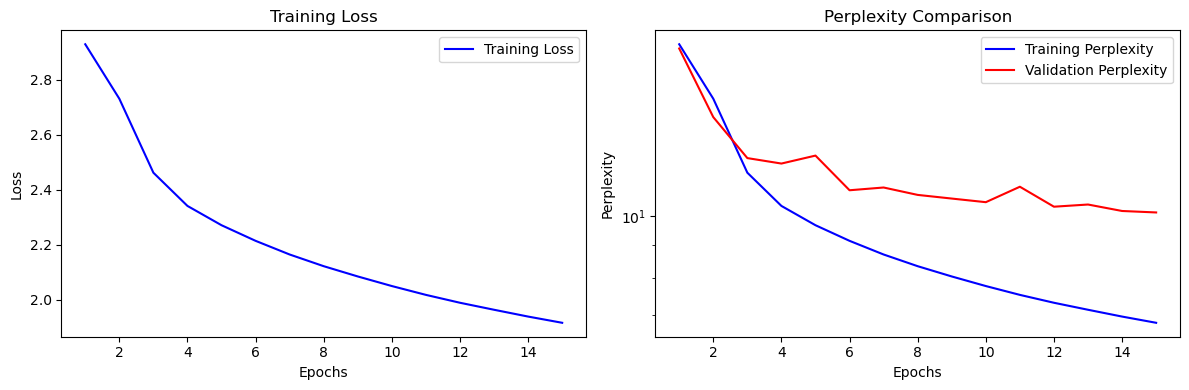

In [49]:
# Después del entrenamiento, graficar curvas
import matplotlib.pyplot as plt

# Extracer datos del historial
train_loss = hist.history['loss']
epochs = range(1, len(train_loss) + 1)

# Perplejidad de entrenamiento (si la guardaste)
train_perplexity = np.exp(train_loss)

# Perplejidad de validación (del callback)
val_perplexity = history_ppl

# Graficar
plt.figure(figsize=(12, 4))

# Subplot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-', label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Subplot 2: Perplejidad
plt.subplot(1, 2, 2)
plt.plot(epochs, train_perplexity, 'b-', label='Training Perplexity')
plt.plot(epochs, val_perplexity, 'r-', label='Validation Perplexity')
plt.title('Perplexity Comparison')
plt.xlabel('Epochs')
plt.ylabel('Perplexity')
plt.legend()
plt.yscale('log')  # Escala logarítmica para perplejidad

plt.tight_layout()
plt.show()

Obervaciones:

- Tanto la pérdida (train_loss) como la perplejidad de entrenamiento (train_perplexity) muestran un descenso continuo y fluido a lo largo de las 15 épocas.

- A partir de la época 4, la perplejidad de validación (val_perplexity) comienza a estancarse y empieza a mostrar fluctuaciones. Mientras el modelo sigue mejorando en el conjunto de entrenamiento. Es posible que esto sea una consecuencia del tamaño del corpus que en validación es pequeño.

- La brecha entre train_perplexity y val_perplexity parece indicar un sobreajuste moderado.

- El modelo ha llegado prácticamente a su límite de aprendizaje alrededor de la época 14. Extender el entrenamiento por más épocas con la arquitectura y los hiperparámetros actuales no mejoraría el rendimiento en validación.

- Generación de secuencias de la LSTM:

In [ ]:
# Semilla inicial
seed = "i want to "

print("GREEDY SEARCH:")
print(generate_seq(model, seed, max_length=max_context_size, n_words=50))

print("\nBEAM SEARCH (Temp=1.0) ---")
salida_det = beam_search(model, num_beams=5, num_words=50, input=seed, mode='det')
print(decode(salida_det[0]))

print("\nBEAM SEARCH (Temp=0.5) ---")
salida_sto_low = beam_search(model, num_beams=5, num_words=50, input=seed, temp=0.5, mode='sto')
print(decode(salida_sto_low[0]))

print("\nBEAM SEARCH (Temp=1.5) ---")
salida_sto_high = beam_search(model, num_beams=5, num_words=50, input=seed, temp=1.5, mode='sto')
print(decode(salida_sto_high[0]))

GREEDY SEARCH:
i want to see the best you can the best you can the best you

BEAM SEARCH (Temp=1.0) ---
i want to the best you can there i'm not you can you can the

BEAM SEARCH (Temp=0.5) ---
i want to the best there you don't reat you can you can the 

BEAM SEARCH (Temp=1.5) ---
i want to it me ster we to you rear e lich a hand your and i


Para recordar, en general:

- Greedy Search: Selecciona el caracter con la probabilidad más alta en cada iteración. 

- Beam Search: Explora simultáneamente un número de caminos definido, calculando las probabilidades conjuntas de secuencias, logrando un texto mucho más coherente a largo plazo.

- La temperatura modifica la distribución Softmax.

- Temperatura baja (T=0.5): Exagera las diferencias de probabilidad, volviendo al modelo conservador y determinista. Produce texto gramaticalmente correcto pero repetitivo.

- Temperatura alta (T=1.5): Aplana la función Softmax, otorgando peso a caracteres estadísticamente menos probables. Esto introduce imprevisibilidad.


Para esta arquitectura, se han memorizado secuencias exactas del corpus de Radiohead debido al sobreajuste (overfitting) diagnosticado en la curva de perplejidad. 

La frase recurrente "the best you can" corresponde a la letra repetitiva de la canción Optimistic. Se puede decir que secuencias frecuentes se memorizaron.

- Greedy Search: Genera un bucle infinito (the best you can the best you can...).

- Beam Search (Determinista): Logra romper la repetición exacta introduciendo nuevas secuencias probabilísticamente altas (there i'm not), pero recae en la misma estructura base.

- Beam Search (Temperatura = 0.2): Con una temperatura baja la función Softmax amplifica las diferencias de probabilidad.

- Beam Search (Temperatura = 1.5): Una temperatura alta aplana la distribución de probabilidades, y fuerza al modelo a seleccionar caracteres estadísticamente menos probables. Esto aumenta drásticamente la creatividad y rompe el bucle (i want to it me ster we to you rear e lich ).

- Arquitecturas: GRU

In [55]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, GRU, Dense, Dropout
from keras.models import Sequential

model_gru = Sequential()
model_gru.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot"), input_shape=(None, 1)))

# Implementación de GRU (Gated Recurrent Unit)
model_gru.add(GRU(128, return_sequences=True, dropout=0.2))
model_gru.add(GRU(128, return_sequences=True, dropout=0.2))

model_gru.add(Dense(vocab_size, activation='softmax'))

model_gru.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model_gru.summary()

/opt/anaconda3/envs/intro_ap/lib/python3.12/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_5              │ (None, None, 44)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 128)      │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, None, 128)      │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, None, 44)       │         5,676 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,564 (670.17 KB)

 Trainable params: 171,564 (670.17 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
history_ppl = []
# Se utiliza el modelo GRU definido previamente
hist_gru = model_gru.fit(
    X, 
    y, 
    epochs=30, 
    callbacks=[PplCallback(tokenized_sentences_val, history_ppl)], 
    batch_size=256
)

Epoch 1/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 1.5667
 mean perplexity: 9.902205459346563 

Saved new model!
207/207 ━━━━━━━━━━━━━━━━━━━━ 59s 285ms/step - loss: 1.5549
Epoch 2/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - loss: 1.5266
 mean perplexity: 9.795754182641932 

Saved new model!
207/207 ━━━━━━━━━━━━━━━━━━━━ 60s 290ms/step - loss: 1.5176
Epoch 3/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - loss: 1.4875
 mean perplexity: 10.537614814926965 

207/207 ━━━━━━━━━━━━━━━━━━━━ 62s 300ms/step - loss: 1.4828
Epoch 4/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - loss: 1.4575
 mean perplexity: 11.41724516546382 

207/207 ━━━━━━━━━━━━━━━━━━━━ 62s 299ms/step - loss: 1.4485
Epoch 5/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - loss: 1.4257
 mean perplexity: 13.076929141974428 

207/207 ━━━━━━━━━━━━━━━━━━━━ 62s 301ms/step - loss: 1.4184
Epoch 6/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - loss: 1.3923
 mean perplexity: 13.09242797662036 

207/207 ━━━━━━━━━━━━━━━━━━━

Se entrena la arquitectura GRU utilizando el mismo callback de perplejidad y Early Stopping para evaluar su convergencia y evitar el sobreajuste. Debido a la menor cantidad de compuertas internas en comparación con LSTM, teóricamente, el tiempo de cómputo por época se reduce, en este caso en realidad aplicó el early stopping recién en la época 7.

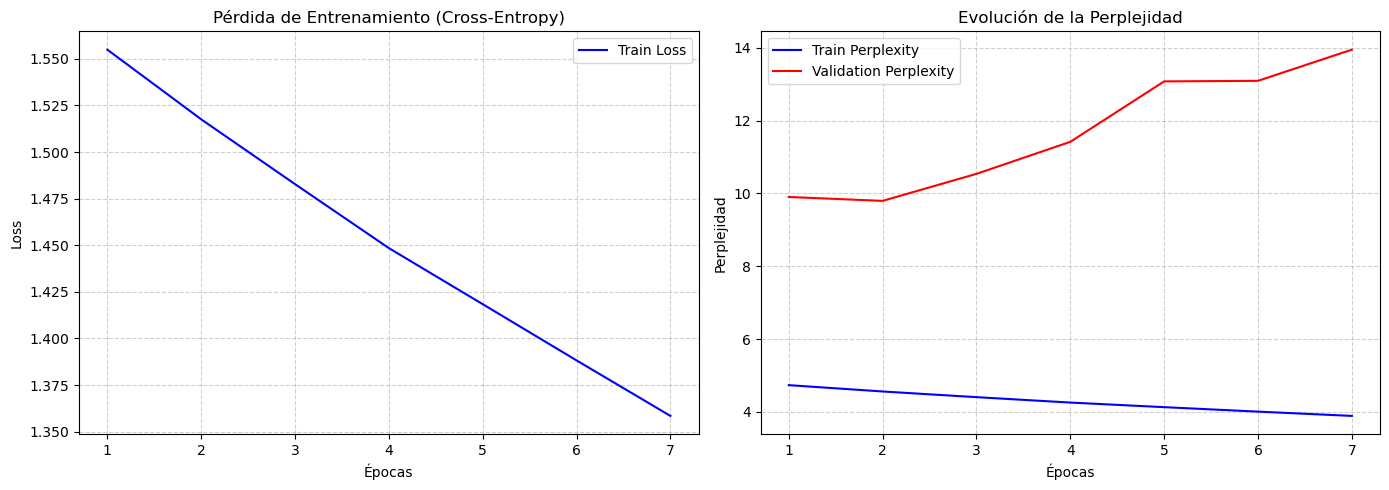

In [72]:
import matplotlib.pyplot as plt
import numpy as np

# Extraer métricas de entrenamiento
train_loss = hist_gru.history['loss']
# La perplejidad teórica de entrenamiento es e^(cross-entropy loss)
train_perp = np.exp(train_loss) 
val_perp = history_ppl 

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(14, 5))

# Gráfica de Pérdida
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-', label='Train Loss')
plt.title('Pérdida de Entrenamiento (Cross-Entropy)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Gráfica de Perplejidad
plt.subplot(1, 2, 2)
plt.plot(epochs, train_perp, 'b-', label='Train Perplexity')
plt.plot(epochs, val_perp, 'r-', label='Validation Perplexity')
plt.title('Evolución de la Perplejidad')
plt.xlabel('Épocas')
plt.ylabel('Perplejidad')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

La gráfica de la perplejidad del modelo GRU muestra un rápido sobreajuste.

La perplejidad de entrenamiento desciende sostenidamente, mientras que la perplejidad de validación alcanza su mínimo óptimo en la segunda época. A partir de la época 3, el error en validación aumenta drásticamente. El callback de Early Stopping intervino correctamente para detener el entrenamiento en la época 7 y conservar los pesos óptimos de la época 2.

In [103]:
# Semilla inicial
seed = "i want to "

print("GREEDY SEARCH:")
print(generate_seq(model_gru, seed, max_length=max_context_size, n_words=50))

print("\nBEAM SEARCH (Temp=1.0) ---")
salida_det = beam_search(model_gru, num_beams=5, num_words=50, input=seed, mode='det')
print(decode(salida_det[0]))

print("\nBEAM SEARCH (Temp=0.5) ---")
salida_sto_low = beam_search(model_gru, num_beams=5, num_words=50, input=seed, temp=0.5, mode='sto')
print(decode(salida_sto_low[0]))

print("\nBEAM SEARCH (Temp=1.5) ---")
salida_sto_high = beam_search(model_gru, num_beams=5, num_words=50, input=seed, temp=1.5, mode='sto')
print(decode(salida_sto_high[0]))

GREEDY SEARCH:
i want to see what is the moon upon a stick a spect lice and

BEAM SEARCH (Temp=1.0) ---
i want to feed you do it to yourself you do it to yourself y

BEAM SEARCH (Temp=0.5) ---
i want to see what is the moon upon a stick and the walls an

BEAM SEARCH (Temp=1.5) ---
i want to know where you to it to yourself you do it to your


- No son muchas muestras en validación y las usa repetidamente.

- El resultado parece más interesante, es como que al haberse activado el early stop, el overfitting es menor en el modelo guardado, y los resultados son un poco más ceativos que en el caso de la LSTM.

- Aunque el beam search con temperatura 1.5 se pone demasiado creativo en "you to it to".

- Arquitectura: GRU con mayor regularización:

In [76]:
from keras.layers import TimeDistributed, CategoryEncoding, GRU, Dense
from keras.models import Sequential
from keras.regularizers import l2
from keras.optimizers import RMSprop

model_reg = Sequential()
model_reg.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot"), input_shape=(None, 1)))

# Se elimina recurrent_dropout para mantener la aceleración de la GPU (Metal)
model_reg.add(GRU(64, 
                  return_sequences=True, 
                  dropout=0.3, 
                  kernel_regularizer=l2(0.001)))

model_reg.add(Dense(vocab_size, activation='softmax'))

optimizer = RMSprop(learning_rate=0.0005)
model_reg.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer)

model_reg.summary()

/opt/anaconda3/envs/intro_ap/lib/python3.12/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_7              │ (None, None, 44)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, None, 64)       │        21,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, None, 44)       │         2,860 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,980 (93.67 KB)

 Trainable params: 23,980 (93.67 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
history_ppl = []

hist_reg = model_reg.fit(
    X, 
    y, 
    epochs=30, 
    callbacks=[PplCallback(tokenized_sentences_val, history_ppl)], 
    batch_size=256
)

Epoch 1/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 3.3697
 mean perplexity: 16.76682656636562 

Saved new model!
207/207 ━━━━━━━━━━━━━━━━━━━━ 64s 301ms/step - loss: 3.0808
Epoch 2/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - loss: 2.7295
 mean perplexity: 13.486667198502214 

Saved new model!
207/207 ━━━━━━━━━━━━━━━━━━━━ 61s 295ms/step - loss: 2.6628
Epoch 3/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - loss: 2.5175
 mean perplexity: 12.19980708538488 

Saved new model!
207/207 ━━━━━━━━━━━━━━━━━━━━ 62s 300ms/step - loss: 2.4918
Epoch 4/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - loss: 2.4303
 mean perplexity: 11.632583498815453 

Saved new model!
207/207 ━━━━━━━━━━━━━━━━━━━━ 61s 293ms/step - loss: 2.4167
Epoch 5/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - loss: 2.3840
 mean perplexity: 11.32014454291642 

Saved new model!
207/207 ━━━━━━━━━━━━━━━━━━━━ 63s 303ms/step - loss: 2.3738
Epoch 6/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - loss: 2.3488
 mean perplexi

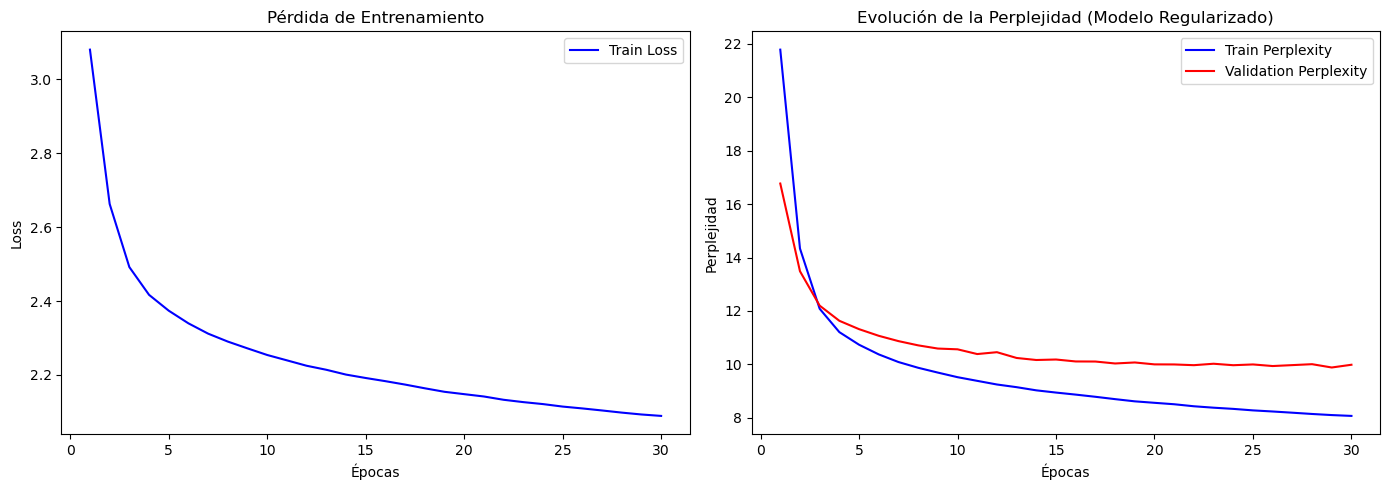

In [78]:
import matplotlib.pyplot as plt
import numpy as np

train_loss = hist_reg.history['loss']
train_perp = np.exp(train_loss) 
val_perp = history_ppl 

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-', label='Train Loss')
plt.title('Pérdida de Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_perp, 'b-', label='Train Perplexity')
plt.plot(epochs, val_perp[:len(train_loss)], 'r-', label='Validation Perplexity')
plt.title('Evolución de la Perplejidad (Modelo Regularizado)')
plt.xlabel('Épocas')
plt.ylabel('Perplejidad')
plt.legend()

plt.tight_layout()
plt.show()

Con regularización, las gráficas son más suaves y no presentan un overfitting tan marcado.
Parecen las mejores hasta ahora, aunque un poco más lento el entrenamiento (sacrificable).

In [105]:
 # Semilla inicial
seed = "i want to "

print("GREEDY SEARCH:")
print(generate_seq(model_reg, seed, max_length=max_context_size, n_words=50))

print("\nBEAM SEARCH (Temp=1.0) ---")
salida_det = beam_search(model_reg, num_beams=5, num_words=50, input=seed, mode='det')
print(decode(salida_det[0]))

print("\nBEAM SEARCH (Temp=0.5) ---")
salida_sto_low = beam_search(model_reg, num_beams=5, num_words=50, input=seed, temp=0.5, mode='sto')
print(decode(salida_sto_low[0]))

print("\nBEAM SEARCH (Temp=1.5) ---")
salida_sto_high = beam_search(model_reg, num_beams=5, num_words=50, input=seed, temp=1.5, mode='sto')
print(decode(salida_sto_high[0]))

GREEDY SEARCH:
i want to seap you alive i will eat you can the bead you ali

BEAM SEARCH (Temp=1.0) ---
i want to you don't weat you alive i will eat you alive it i

BEAM SEARCH (Temp=0.5) ---
i want to the east the eart the eat you can the will eat you

BEAM SEARCH (Temp=1.5) ---
i want to kear the blot ie your cimet rown the sot your a pw


- Bueno el temp. 1.5 hizo que la secuencia pierda todo el sentido.
- Probaría este mismo modelo un poco más con un corpus más grande, quizas con data augmentation.

- Arquitectura: SimpleRNN

In [98]:
from keras.layers import TimeDistributed, CategoryEncoding, SimpleRNN, Dense, Dropout
from keras.models import Sequential
from keras.optimizers import RMSprop

model_rnn = Sequential(name="SimpleRNN")
model_rnn.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot"), input_shape=(max_context_size, 1)))

# 1. Una sola capa más ancha (procesa todo en una sola pasada temporal)
# 2. unroll=True: Desenrolla el bucle for interno, acelerando drásticamente el cálculo a costa de memoria
model_rnn.add(SimpleRNN(256, return_sequences=True, unroll=True))

# 3. Dropout por fuera: Mantiene el núcleo de la RNN libre de operaciones extra
model_rnn.add(Dropout(0.2))

model_rnn.add(Dense(vocab_size, activation='softmax'))

model_rnn.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model_rnn.summary()

/opt/anaconda3/envs/intro_ap/lib/python3.12/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_10             │ (None, 100, 44)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 100, 256)       │        77,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100, 44)        │        11,308 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,364 (345.17 KB)

 Trainable params: 88,364 (345.17 KB)

 Non-trainable params: 0 (0.00 B)


Simple RNN. 
En teoría las redes recurrentes clásicas sufren el problema de vanishing gradient (desvanecimiento del gradiente) al procesar secuencias largas (100 caracteres). 


In [99]:
history_ppl = []

# Entrenamiento del modelo SimpleRNN
hist_rnn = model_rnn.fit(
    X, 
    y, 
    epochs=30, 
    callbacks=[PplCallback(tokenized_sentences_val, history_ppl)], 
    batch_size=256
)

Epoch 1/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - loss: 2.6816
 mean perplexity: 12.720727457933242 

Saved new model!
207/207 ━━━━━━━━━━━━━━━━━━━━ 75s 338ms/step - loss: 2.3435
Epoch 2/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - loss: 1.8916
 mean perplexity: 15.725913178437054 

207/207 ━━━━━━━━━━━━━━━━━━━━ 70s 339ms/step - loss: 1.8356
Epoch 3/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - loss: 1.6948
 mean perplexity: 16.28810165205111 

207/207 ━━━━━━━━━━━━━━━━━━━━ 73s 353ms/step - loss: 1.6581
Epoch 4/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - loss: 1.5567
 mean perplexity: 22.3638775460156 

207/207 ━━━━━━━━━━━━━━━━━━━━ 69s 334ms/step - loss: 1.5312
Epoch 5/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - loss: 1.4540
 mean perplexity: 21.63993925418599 

207/207 ━━━━━━━━━━━━━━━━━━━━ 69s 334ms/step - loss: 1.4349
Epoch 6/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - loss: 1.3739
 mean perplexity: 22.916208731285316 

Stopping training...
207/207 ━━━━━━━━━━━━━━━

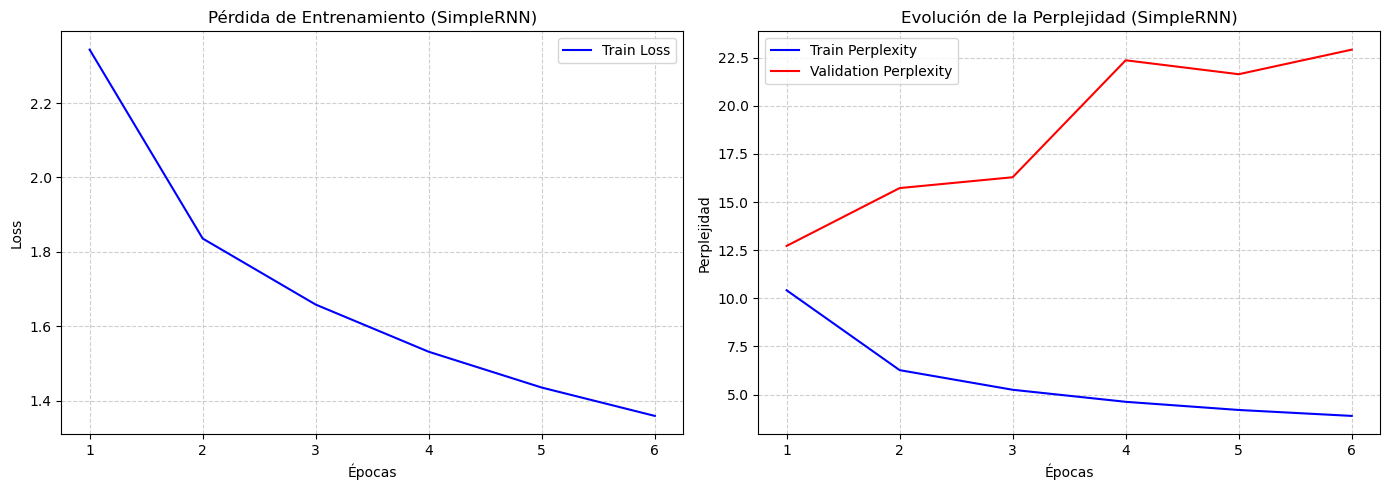

In [104]:
import matplotlib.pyplot as plt
import numpy as np

# Extracción de métricas
train_loss_rnn = hist_rnn.history['loss']
train_perp_rnn = np.exp(train_loss_rnn) 
val_perp_rnn = history_ppl 

epochs_rnn = range(1, len(train_loss_rnn) + 1)

plt.figure(figsize=(14, 5))

# Gráfica de Pérdida
plt.subplot(1, 2, 1)
plt.plot(epochs_rnn, train_loss_rnn, 'b-', label='Train Loss')
plt.title('Pérdida de Entrenamiento (SimpleRNN)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Gráfica de Perplejidad
plt.subplot(1, 2, 2)
plt.plot(epochs_rnn, train_perp_rnn, 'b-', label='Train Perplexity')
plt.plot(epochs_rnn, val_perp_rnn[:len(train_loss_rnn)], 'r-', label='Validation Perplexity')
plt.title('Evolución de la Perplejidad (SimpleRNN)')
plt.xlabel('Épocas')
plt.ylabel('Perplejidad')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

Tienede a empeorar casi en todas las épocas.

In [106]:
 # Semilla inicial
seed = "i want to "

print("GREEDY SEARCH:")
print(generate_seq(model_rnn, seed, max_length=max_context_size, n_words=50))

print("\nBEAM SEARCH (Temp=1.0) ---")
salida_det = beam_search(model_rnn, num_beams=5, num_words=50, input=seed, mode='det')
print(decode(salida_det[0]))

print("\nBEAM SEARCH (Temp=0.5) ---")
salida_sto_low = beam_search(model_rnn, num_beams=5, num_words=50, input=seed, temp=0.5, mode='sto')
print(decode(salida_sto_low[0]))

print("\nBEAM SEARCH (Temp=1.5) ---")
salida_sto_high = beam_search(model_rnn, num_beams=5, num_words=50, input=seed, temp=1.5, mode='sto')
print(decode(salida_sto_high[0]))

GREEDY SEARCH:
i want to puen the isese hou heal you don't tome ingi don't 

BEAM SEARCH (Temp=1.0) ---
i want to the where in the back and you don't heat youn the 

BEAM SEARCH (Temp=0.5) ---
i want to ke way u don't you ande in is ill hath th ain the 

BEAM SEARCH (Temp=1.5) ---
i want to ke wang te the dinctus allang inginging that ingat


A diferencia de los modelos LSTM y GRU, los resultados de la generación de texto con la arquitectura SimpleRNN (Celda de Elman) son prácticamente ininteligibles ("*puen the isese hou heal*", "*dinctus allang*"). El modelo apenas logra formar palabras cortas aisladas y falla completamente en la coherencia a nivel de frase, independientemente de la estrategia de decodificación (Greedy o Beam Search) o de la temperatura aplicada.

Este comportamiento evidencia el problema del desvanecimiento del gradiente (Vanishing Gradient). Al procesar secuencias largas (ventana de contexto de 100 caracteres), la red es incapaz de retener dependencias a largo plazo porque carece de los mecanismos de compuertas (estado de celda, compuerta de olvido/entrada) que poseen LSTM y GRU. 